<img src="imgs/unifor_logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br>
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos para Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>

<p dir="ltr" style="text-align: left;">
    <strong>Links:</strong>
    <a href="https://www2.unifor.br/controle_pesquisa/pesquisarprofessor.do?actionParameter=prepareUpdate&amp;p_tp_ambiente=2&amp;p_tp_chamada=1&amp;p_tp_apresentacao=1&amp;cdPesquisador=767686193" target="_blank">Unifor</a> |
    <a href="http://lattes.cnpq.br/5738786447903616" target="_blank">Lattes</a> |
    <a href="https://unifor.br/web/pesquisa-inovacao/ncdia" target="_blank">NCDIA</a> |
    <a href="https://github.com/carubbi/" target="_blank">Github</a>
</p>

# **Estatística Básica - Conceitos e Aplicações**

## **Configurações Iniciais**

In [46]:
# Bibliotecas para manipulação de dados, estatística e gráficos
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


In [47]:
# Ajustes visuais padrão para manter os gráficos legíveis
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "STIXGeneral"],
    'figure.figsize': (7, 4.5),
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


## **Dataset**

In [ ]:
# Leitura do arquivo CSV para o DataFrame principal
df = pd.read_csv('../../dataset/api.csv')
# Primeiras linhas para inspeção inicial dos dados
df.head()


,ID,TIPO,NOME,API00,API99,META,EDU,TEST_INSC,TEST_NUM,REFS,NPI
0,1611190130229,Superior,Alameda High,731,693,5,3.45,1278,1090,14,16
1,1611190132878,Superior,Encinal High,622,589,11,3.06,1113,840,20,18
2,1611196000004,Medio,Chipman Middle,622,572,11,2.82,546,472,55,25
3,1611196090005,Fundamental,Lum (Donald D.),774,732,3,3.32,330,272,35,26
4,1611196090013,Fundamental,Edison Elementa,811,784,1,3.76,233,216,15,9


In [49]:
# Estrutura do DataFrame: tipos, nulos e volume de dados
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5423 entries, 0 to 5422
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         5423 non-null   int64  
 1   TIPO       5423 non-null   str    
 2   NOME       5423 non-null   str    
 3   API00      5423 non-null   int64  
 4   API99      5423 non-null   int64  
 5   META       5423 non-null   int64  
 6   EDU        5423 non-null   float64
 7   TEST_INSC  5423 non-null   int64  
 8   TEST_NUM   5423 non-null   int64  
 9   REFS       5423 non-null   int64  
 10  NPI        5423 non-null   int64  
dtypes: float64(1), int64(8), str(2)
memory usage: 466.2 KB


## **Medidas de Dispersão**

As medidas de tendência central, como a média, a mediana e a moda, **não revelam** todo o panorama da distribuição de um conjunto de dados. Dois conjuntos de dados com a **mesma média** podem apresentar **dispersões completamente diferentes**. A variação entre os valores das observações de um conjunto de dados pode ser muito maior ou muito menor do que a de outro conjunto. Assim, a média, a mediana ou a moda, isoladamente, geralmente **não são suficientes** para revelar a forma da distribuição de um conjunto de dados. Também é necessária uma medida que forneça informações sobre a **variação entre os valores dos dados**. Essas medidas são chamadas de **medidas de dispersão**. As medidas de tendência central e de dispersão, quando consideradas em conjunto, fornecem uma **descrição mais completa** de um conjunto de dados do que as medidas de tendência central isoladamente (Mann, 2012).

<p align="center">
  <img src="imgs/assimetrias.png" width="600">
</p>

**Fig. 1 - Comparação de distribuições em termos de posição central, dispersão, assimetria e curtose**. Em **A**, as distribuições diferem quanto à **posição central**: picos deslocados indicam médias/medianas em níveis distintos. Em **B**, diferem quanto à **dispersão**: curvas mais largas indicam maior variabilidade e curvas mais estreitas, menor variabilidade. Em **C**, diferem quanto à **assimetria**: cauda à direita sugere concentração em valores menores com alguns valores altos, enquanto cauda à esquerda sugere o oposto. Em **D**, diferem quanto à **curtose**: perfis mais afilados com caudas mais pesadas indicam maior concentração central e maior probabilidade de valores extremos; perfis mais achatados indicam menor concentração central. Fonte: Barbetta, 2010.

### **Variância**


A **variância** quantifica a **dispersão** dos dados em torno da **média** por meio do quadrado dos **desvios**. Para dados populacionais, ela é denotada por **$\sigma^2$** (lê-se sigma ao quadrado), chamada de **variância populacional**; para dados amostrais, é denotada por **$s^2$** (lê-se s ao quadrado), chamada de **variância amostral**. Matematicamente, tem-se:

$$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N}(x_i-\mu)^2 \tag{1}$$

$$s^2 = \frac{1}{n-1} \sum_{i=1}^{n}(x_i-\bar{x})^2 \tag{2}$$

onde **$x_i$** é a $i$-ésima observação, **$\mu$** é a média populacional, **$\bar{x}$** é a média amostral, **$N$** é o tamanho da população e **$n$** é o tamanho da amostra. Neste notebook, **$x_i$**, **$\mu$** e **$\bar{x}$** estão em **pontos de API**; assim, **$\sigma^2$** e **$s^2$** ficam em **(pontos de API)$^2$**. As constantes **$N$**, **$n$** e **$n-1$** são contagens e, portanto, não têm unidade física. As quantidades **$(x_i-\mu)$** e **$(x_i-\bar{x})$** são os desvios da observação $x_i$ em relação à respectiva média.

Na expressão amostral, o denominador **$n-1$** aplica a **correção de Bessel** porque a média amostral **$\bar{x}$** é estimada com os próprios dados, impondo a restrição $\sum_{i=1}^{n}(x_i-\bar{x})=0$ e deixando apenas **$n-1$** desvios livres (**graus de liberdade**); por isso, essa correção reduz o viés de subestimação na estimativa da variância populacional.

Assim, quanto maiores **$\sigma^2$** e **$s^2$**, maior é a dispersão dos dados em torno da média, indicando menor homogeneidade do conjunto (Mann, 2012).

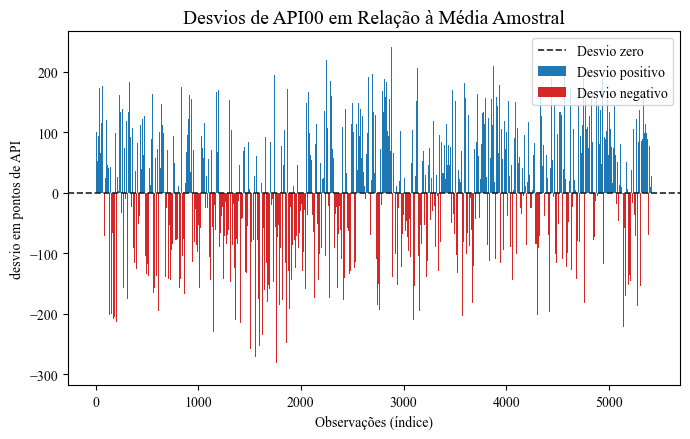

In [50]:
# Variável numérica usada para estudar dispersão
var = 'API00'
# Unidade da variável (escala do índice API)
unidade = 'pontos de API'
# Série sem valores ausentes para cálculo da média e dos desvios
x = df[var].dropna()
# Média amostral da variável
x_bar = x.mean()
# Desvio de cada observação em relação à média
desvios = x - x_bar
# Índice sequencial para o eixo x do gráfico
idx = np.arange(1, len(desvios) + 1)

# Máscaras lógicas para separar desvios positivos e negativos
pos = desvios >= 0
neg = ~pos

# Criação da figura e do eixo principal
fig, ax = plt.subplots()
# Barras azuis para desvios positivos
ax.bar(
    idx[pos],
    desvios[pos],
    color='#1f77b4',
    width=1.0,
    edgecolor='none',
    label='Desvio positivo',
)
# Barras vermelhas para desvios negativos
ax.bar(
    idx[neg],
    desvios[neg],
    color='#d62728',
    width=1.0,
    edgecolor='none',
    label='Desvio negativo',
)
# Linha horizontal de referência no desvio zero
ax.axhline(
    0,
    color='#222222',
    linewidth=1.2,
    linestyle='--',
    label='Desvio zero',
)

# Título, rótulos e legenda para leitura do gráfico
ax.set_title(f'Desvios de {var} em Relação à Média Amostral')
ax.set_xlabel('Observações (índice)')
ax.set_ylabel('desvio em pontos de API')
ax.legend(loc='upper right', frameon=True)

# Ajuste de layout e exibição final
plt.tight_layout()
plt.show()


**Fig. 2** **Desvios de API00 em relação à média amostral.** Cada barra representa o desvio $x_i-\bar{x}$ de uma observação da variável $\mathrm{API00}$, medido em **pontos de API**; barras acima de zero indicam desvios positivos e barras abaixo de zero indicam desvios negativos. Para este conjunto, tem-se $n=5423$ observações válidas e, portanto, $n-1=5422$ graus de liberdade na variância amostral. A compensação entre desvios positivos e negativos (com soma aproximadamente nula) sustenta a interpretação de dispersão em torno da média e fundamenta o uso da correção de Bessel no estimador $s^2$. Fonte: Carubbi, 2026.

In [51]:
# Resumo numérico para interpretar o gráfico de desvios
s2 = desvios.pow(2).sum() / (len(x) - 1)
print(f'Média amostral de {var}: {x_bar:.4f} pts')
print(f'Soma dos desvios (aprox. 0): {desvios.sum():.12f} pts')
print(f'Variância amostral (s²): {s2:.4f} pts²')
print(f'Tamanho da amostra (n): {len(x)} observações')
print(f'Graus de liberdade (n-1): {len(x)-1}')

Média amostral de API00: 637.5611 pts
Soma dos desvios (aprox. 0): -0.000000000196 pts
Variância amostral (s²): 12246.2050 pts²
Tamanho da amostra (n): 5423 observações
Graus de liberdade (n-1): 5422


### **Desvio Padrão**


O **desvio padrão** é a medida de dispersão mais utilizada. O valor do desvio padrão indica o **quão próximos** os valores de um conjunto de dados estão agrupados em torno da média. Em geral, um **valor menor** de desvio padrão indica que os valores do conjunto de dados estão distribuídos em um **intervalo relativamente menor em torno da média**. Em contraste, um **valor maior** de desvio padrão indica que os valores do conjunto de dados estão distribuídos em um **intervalo relativamente maior em torno da média** (Mann, 2012).

O desvio padrão é obtido tomando-se a raiz quadrada da variância. Consequentemente, o desvio padrão calculado para dados populacionais é denotado por $\sigma$, e o desvio padrão calculado para dados amostrais é denotado por $s$.

Para população e amostra, respectivamente:

$$\sigma = \sqrt{\sigma^2} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(x_i-\mu)^2} \tag{3}$$

$$s = \sqrt{s^2} = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2} \tag{4}$$

onde $\sigma$ é o desvio padrão da população e $s$ é o desvio padrão da amostra.

##### **Exemplo 1**


Considere o conjunto de dados `api.csv`. Para este exercício, use a variável `API00` (**índice de desempenho acadêmico no ano 2000**).

a. Extraia os **valores válidos** de `API00` e determine o tamanho da amostra ($n$).  
b. Implemente, sem `np.std`, uma função para calcular o **desvio padrão amostral** com base em $s=\sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2}$.  
c. Calcule o **desvio padrão amostral** de `API00` com sua função e compare com o resultado de `numpy` (`np.std` com `ddof=1`).  
d. Interprete, de forma breve, o valor obtido no contexto da dispersão dos desempenhos escolares.

##### **Resposta**


In [52]:
# Item (a): extrair valores válidos e tamanho da amostra
api00 = df['API00'].dropna()
n = len(api00)
print(f'n (API00): {n} observações')

n (API00): 5423 observações


In [53]:
# Item (b): função de desvio padrão amostral sem np.std
def desvio_padrao_amostral(valores):
    valores = np.asarray(valores, dtype=float)
    n = valores.size
    if n < 2:
        raise ValueError('A amostra deve ter pelo menos 2 valores.')
    media = valores.mean()
    variancia = ((valores - media) ** 2).sum() / (n - 1)
    return np.sqrt(variancia)


In [54]:
# Item (c): cálculo próprio e comparação com numpy
s_api00_func = desvio_padrao_amostral(api00)
s_api00_np = np.std(api00, ddof=1)
dif = abs(s_api00_func - s_api00_np)
print(f's (função própria): {s_api00_func:.4f} pontos')
print(f's (numpy, ddof=1): {s_api00_np:.4f} pontos')
print(f'diferença absoluta: {dif:.12f} ponto(s)')


s (função própria): 110.6626 pontos
s (numpy, ddof=1): 110.6626 pontos
diferença absoluta: 0.000000000000 ponto(s)


**Item (d) - Interpretação**

O desvio padrão amostral de `API00` mede o afastamento típico dos valores em torno da média, em **pontos**. Quanto maior esse valor, maior a heterogeneidade de desempenho entre as escolas da amostra.

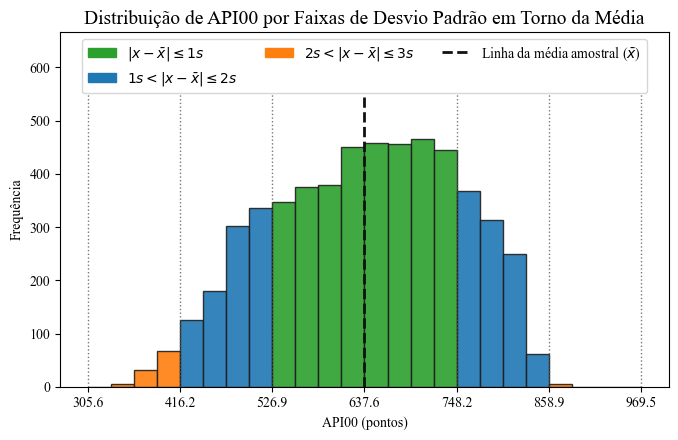

In [55]:
# Dados e medidas de posição/escala para API00
api00 = df['API00'].dropna()
x_bar = api00.mean()
s = api00.std(ddof=1)
d = 4
# Validação: d deve ser inteiro positivo
if not isinstance(d, (int, np.integer)) or d <= 0:
    raise ValueError('d deve ser inteiro positivo (ex.: 1, 2, 4).')
# Bordas com largura proporcional a s e ancoradas em x_bar
xmin = api00.min()
xmax = api00.max()
k_left = int(np.ceil((x_bar - xmin) / s))
k_right = int(np.ceil((xmax - x_bar) / s))
left_edge = x_bar - k_left * s
right_edge = x_bar + k_right * s
bins = np.arange(left_edge, right_edge + s / d, s / d)
# Frequências por classe e centros das barras
freq, edges = np.histogram(api00, bins=bins)
widths = np.diff(edges)
centers = edges[:-1] + widths / 2
# Distância de cada barra à média em unidades de s
z = np.abs((centers - x_bar) / s)
# Cores por faixa de desvio padrão (até 3s)
colors = np.where(
    z <= 1, '#2ca02c',
    np.where(z <= 2, '#1f77b4', '#ff7f0e')
)
fig, ax = plt.subplots()
ax.bar(
    edges[:-1],
    freq,
    width=widths,
    align='edge',
    color=colors,
    edgecolor='#1f1f1f',
    alpha=0.9,
)
# Linha vertical da média amostral
ax.vlines(
    x_bar,
    0,
    550,
    color='#111111',
    linestyle='--',
    linewidth=2.0,
)
# Linhas dos limites das faixas (sem entrada na legenda)
for k in range(1, 4):
    ax.vlines(
        x_bar - k * s,
        0,
        550,
        color='#555555',
        linestyle=':',
        linewidth=1.0,
        alpha=0.8,
    )
    ax.vlines(
        x_bar + k * s,
        0,
        550,
        color='#555555',
        linestyle=':',
        linewidth=1.0,
        alpha=0.8,
    )
ax.set_title(
    'Distribuição de API00 por Faixas de Desvio Padrão em Torno '
    'da Média'
)
ax.set_xlabel('API00 (pontos)')
ax.set_ylabel('Frequência')

# Ticks em x alinhados aos limites das faixas de desvio padrão
k_vals = np.arange(-k_left, k_right + 1)
x_ticks = x_bar + k_vals * s
x_ticks = x_ticks[(x_ticks >= left_edge) & (x_ticks <= right_edge)]
ax.set_xticks(x_ticks)

# Escala do eixo Y: máximo observado + 200 unidades
y_max = int(freq.max() + 200)
ax.set_ylim(0, y_max)

# Marcação do eixo Y de 100 em 100
ax.set_yticks(np.arange(0, y_max + 1, 100))

# Legenda das faixas coloridas
legend_items = [
    Patch(color='#2ca02c', label=r'$|x-\bar{x}| \leq 1s$'),
    Patch(color='#1f77b4', label=r'$1s < |x-\bar{x}| \leq 2s$'),
    Patch(color='#ff7f0e', label=r'$2s < |x-\bar{x}| \leq 3s$'),
    Line2D(
        [0], [0],
        color='#111111',
        linestyle='--',
        linewidth=2.0,
        label=r'Linha da média amostral ($\bar{x}$)',
    ),
]

# Elementos da legenda adicionados ao gráfico
ax.legend(
    handles=legend_items, 
    loc='upper center', 
    ncols=3,
    frameon=True
)
plt.tight_layout()
plt.show()


**Fig. 3** **Histograma de API00 com faixas em unidades de desvio padrão.** As barras foram classificadas pela distância à média amostral $\bar{x}$: até $1s$, entre $1s$ e $2s$, e entre $2s$ e $3s$, com uma linha vertical indicando $\bar{x}$. Como os limites das classes foram construídos com largura proporcional a $s$, os cortes em $\bar{x}\pm ks$ ($k=1,2,3$) ficam alinhados às divisões do histograma. Essa visualização permite comparar concentração central e dispersão dos dados no conjunto `API00`. Fonte: Carubbi, 2026.

In [56]:
# Proporções observadas dentro de xbarra±ks
n = api00.size
for k in range(1, 4):
    lim_inf = x_bar - k * s
    lim_sup = x_bar + k * s
    dentro = ((api00 >= lim_inf) & (api00 <= lim_sup)).sum()
    prop = dentro / n
    print(
        f'k={k}: {dentro}/{n} observações '
        f'({prop:.2%}) em [x̄-{k}s, x̄+{k}s]'
    )

k=1: 3377/5423 observações (62.27%) em [x̄-1s, x̄+1s]
k=2: 5312/5423 observações (97.95%) em [x̄-2s, x̄+2s]
k=3: 5423/5423 observações (100.00%) em [x̄-3s, x̄+3s]


### **Teorema de Chebyshev**

Ao utilizar a **média** e o **desvio padrão**, podemos determinar a proporção ou porcentagem do total de observações que se encontram dentro de um determinado intervalo em torno da média. O **teorema de Chebyshev** fornece um **limite inferior** para a **proporção de dados** contida entre dois pontos que estão em lados opostos da média e à mesma distância dela.

Para qualquer número **$k$** maior que **$1$**, pelo menos **$1-\frac{1}{k^2}$** dos valores dos dados estão situados a até **$k$ desvios padrão da média**.

In [57]:
# Grade de valores de k (válido para k > 1)
k = np.arange(1, 4, 0.1)
# Limite inferior de Chebyshev para cada valor de k
limite_chebyshev = 1 - (1 / k**2)
# Conversão para porcentagem inteira para visualização
limite_percentual = np.round(limite_chebyshev * 100, 0)
# Tabela auxiliar com k e limite percentual
limite_df = pd.DataFrame(
    data=zip(k, limite_percentual),
    columns=["k", "limite_percentual"]
)
limite_df


,k,limite_percentual
0,1.0,0.0
1,1.1,17.0
2,1.2,31.0
3,1.3,41.0
4,1.4,49.0
5,1.5,56.0
6,1.6,61.0
7,1.7,65.0
8,1.8,69.0
9,1.9,72.0


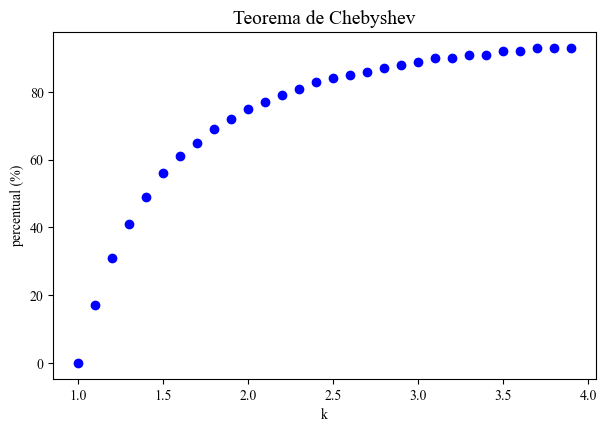

In [58]:
# Exemplo de k inteiro para consulta rápida em sala
random.seed(3)
random_k = random.sample(list(range(2, 5)), 1)[0]
percentual = round((1 - (1 / random_k**2)) * 100)

# Gráfico de pontos do limite de Chebyshev em função de k
plt.plot(
    k,
    limite_percentual,
    color="blue",
    linestyle="",
    marker="o",
    label="Limite inferior de Chebyshev",
)
plt.title("Teorema de Chebyshev")
plt.xlabel("k")
plt.ylabel("percentual (%)")

plt.show()

**Fig. 4** **Limite inferior do Teorema de Chebyshev em função de $k$.** Cada ponto representa o valor percentual de $1-\frac{1}{k^2}$ para $k>1$. O gráfico evidencia que, à medida que $k$ aumenta, o limite inferior também aumenta, indicando uma fração mínima maior de observações dentro do intervalo $\bar{x}\pm ks$. Fonte: Carubbi, 2026.

In [59]:
# Aplicação do Teorema de Chebyshev em API00
api00 = df['API00'].dropna()
x_bar = api00.mean()
s = api00.std(ddof=1)
n = api00.size

# Valores de k para análise (k > 1)
k_values = [2, 3]

for k in k_values:
    lim_inf = x_bar - k * s
    lim_sup = x_bar + k * s
    teorico_min = 1 - 1 / (k ** 2)
    obs_count = ((api00 >= lim_inf) & (api00 <= lim_sup)).sum()
    obs_prop = obs_count / n
    print(f'k={k}')
    print(
        f'intervalo: [{lim_inf:.2f}, {lim_sup:.2f}] pontos'
    )
    print(
        f'limite teórico mínimo (Chebyshev): {teorico_min:.2%}'
    )
    print(f'proporção observada no dataset: {obs_prop:.2%}')
    print('-' * 50)


k=2
intervalo: [416.24, 858.89] pontos
limite teórico mínimo (Chebyshev): 75.00%
proporção observada no dataset: 97.95%
--------------------------------------------------
k=3
intervalo: [305.57, 969.55] pontos
limite teórico mínimo (Chebyshev): 88.89%
proporção observada no dataset: 100.00%
--------------------------------------------------


**Interpretação da aplicação**

O teorema fornece uma **garantia mínima** para a fração de escolas com `API00` dentro de $\bar{x}\pm ks$, sem exigir distribuição normal. Compare a proporção observada com o limite teórico: se o valor observado for maior, o resultado é consistente com Chebyshev no conjunto analisado.

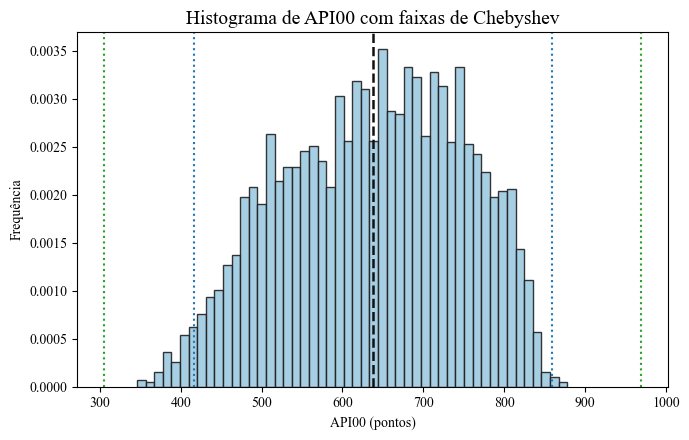

In [60]:
# Histograma para validação empírica de Chebyshev
api00 = df['API00'].dropna()
x_bar = api00.mean()
s = api00.std(ddof=1)
n = api00.size

# Faixas escolhidas para avaliação
k_values = [2, 3]
intervalos = {}
for k in k_values:
    lim_inf = x_bar - k * s
    lim_sup = x_bar + k * s
    teorico = 1 - 1 / (k ** 2)
    observado = ((api00 >= lim_inf) & (api00 <= lim_sup)).mean()
    intervalos[k] = (lim_inf, lim_sup, teorico, observado)

fig, ax = plt.subplots()
ax.hist(
    api00,
    bins=50,
    density=True,
    color='#9ecae1',
    edgecolor='#1f1f1f',
    alpha=0.9,
)

# Linhas de referência para os limites de k=2 e k=3
ax.axvline(x_bar, color='#111111', linestyle='--', linewidth=1.8)
for k, cor in [(2, '#1f77b4'), (3, '#2ca02c')]:
    ax.axvline(
        intervalos[k][0],
        color=cor,
        linestyle=':',
        linewidth=1.5,
    )
    ax.axvline(
        intervalos[k][1],
        color=cor,
        linestyle=':',
        linewidth=1.5,
    )

ax.set_title('Histograma de API00 com faixas de Chebyshev')
ax.set_xlabel('API00 (pontos)')
ax.set_ylabel('Frequência')
plt.tight_layout()
plt.show()


**Fig. 5** **Histograma de API00 com limites de Chebyshev (k=2 e k=3).** Linhas verticais pontilhadas indicam os limites $\bar{x}\pm2s$ e $\bar{x}\pm3s$, e a linha tracejada marca $\bar{x}$. A saída numérica compara, para cada $k$, a proporção observada no dataset com o limite inferior teórico $1-1/k^2$, validando empiricamente a desigualdade no conjunto analisado. Fonte: Carubbi, 2026.

In [61]:
# Comparação observado versus limite teórico
for k in k_values:
    _, _, teorico, observado = intervalos[k]
    print(f'k={k}: observado={observado:.2%} | mínimo teórico={teorico:.2%}')

k=2: observado=97.95% | mínimo teórico=75.00%
k=3: observado=100.00% | mínimo teórico=88.89%


O teorema aplica-se tanto a dados amostrais quanto a dados populacionais. Observe que o teorema de Chebyshev é válido para distribuições de qualquer forma. Entretanto, ele só pode ser utilizado para valores de $k$ maiores que $1$. Isso ocorre porque, quando $k = 1$, o valor de $\left(1 - \frac{1}{k^2}\right)$ é zero, e quando $k < 1$, o valor de $\left(1 - \frac{1}{k^2}\right)$ é negativo (Mann, 2012).

### **Regra Empírica**

Enquanto o teorema de Chebyshev é aplicável a distribuições de qualquer forma, a regra empírica aplica-se apenas a um tipo específico de distribuição, chamada **distribuição em forma de sino ou distribuição normal**. Essa regra estabelece três resultados aproximados:

- 68% das observações estão dentro de um desvio padrão em relação à média;	
- 95% das observações estão dentro de dois desvios padrão em relação à média;	
- 99,7% das observações estão dentro de três desvios padrão em relação à média.	
	
	

In [62]:
# Gerando uma amostra de dados normais (media 0 e desvio padrão 1)
y_norm = np.random.normal(loc=0, scale=1, size=100000)
y_norm[:100]

array([ 1.35504564,  0.89236238, -1.08430892,  0.59811589,  0.81436664,
       -1.02893499, -0.24970466, -1.00597179,  1.5317353 , -1.15778947,
        0.59054556, -0.18424509,  1.25799844,  0.74276598,  1.41651192,
        0.56347831,  1.82138355,  2.17180596, -0.10035104, -1.57321689,
        0.64969473,  0.65504086,  0.79261335, -0.41921687,  0.27556283,
       -0.73298553, -0.72888427, -0.04433151,  0.28917965,  0.74475658,
        0.05941808, -1.33674913, -1.37565859,  0.56739838, -0.23268258,
       -2.12011123, -2.01430317,  1.52597501,  0.05359777,  2.39631285,
       -2.71807436,  1.14862533,  0.92988315, -1.1362086 , -0.99926951,
        1.88948794, -0.34580357,  0.12882916, -0.88696219,  1.14809202,
        0.54802179,  1.3269775 , -0.80913012, -1.11023226, -0.87930277,
        1.18175987, -0.94959362, -0.13197343, -0.99227441,  0.02367803,
        1.45057395, -0.6043105 ,  1.28201484,  1.79189864, -0.80724795,
        2.36846633,  0.27648517,  1.52219894,  0.54081342,  1.30

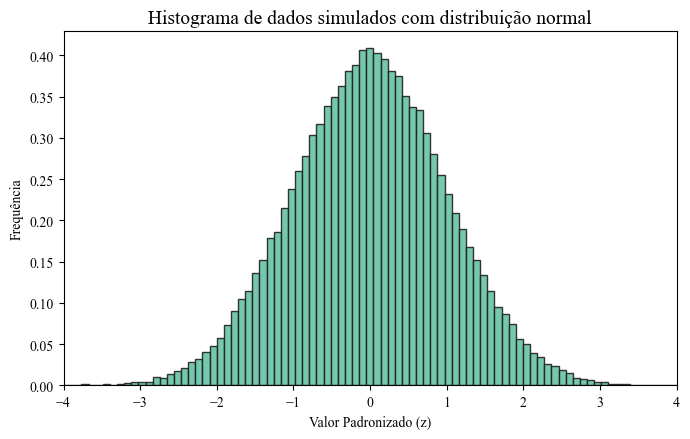

In [63]:
# Histograma dos dados normais gerados em y_norm
fig, ax = plt.subplots()
ax.hist(
    y_norm,
    bins=100,
    density=True,
    color='#66c2a5',
    edgecolor='#1f1f1f',
    alpha=0.9,
)
ax.set_title('Histograma de dados simulados com distribuição normal')
ax.set_xlabel('Valor Padronizado (z)')
ax.set_ylabel('Frequência')
ax.set_xlim(-4, 4)
plt.tight_layout()
plt.show()

**Fig. 6** **Histograma da amostra normal aleatória (`y_norm`).** O gráfico apresenta a distribuição simulada com média próxima de 0 e desvio padrão próximo de 1, em escala de densidade. A forma aproximadamente simétrica e em sino serve como referência visual para a Regra Empírica. Fonte: Carubbi, 2026.

In [64]:
# Cálculo das proporções dentro de 1, 2 e 3 desvios padrão para a amostra normal
sd1 = len(y_norm[(y_norm > -1) & (y_norm < 1)]) / len(y_norm) * 100
sd2 = len(y_norm[(y_norm > -2) & (y_norm < 2)]) / len(y_norm) * 100
sd3 = len(y_norm[(y_norm > -3) & (y_norm < 3)]) / len(y_norm) * 100

pd.DataFrame({"sd": ["1sd", "2sd", "3sd"], "value": [sd1, sd2, sd3]})

,sd,value
0,1sd,68.181
1,2sd,95.430
2,3sd,99.691


Correspondência perfeita! As três regras empíricas são claramente válidas. Para visualizar nossos resultados, replotamos o histograma e adicionamos algumas anotações. Observe que, na função `plt.hist()`, definimos o argumento `density = 1`. Como consequência, o histograma resultante não mostra mais contagens no eixo y, mas sim valores de densidade (contagem normalizada dividida pela largura da classe), o que significa que a soma das áreas das barras é igual a 1.

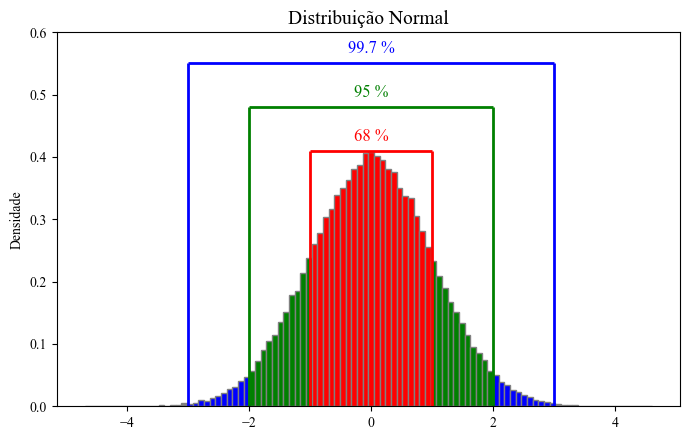

In [65]:
# Histograma de y_norm com barras coloridas por faixa de desvio padrão
y_norm = pd.Series(y_norm)
fig, ax = plt.subplots()
counts, bin_edges, bars = ax.hist(
    y_norm,
    bins=100,
    density=True,
    color='lightgrey',
    edgecolor='grey',
)

# Coloração das barras por faixa de desvio padrão
for bar in bars:
    x = bar.get_x() + 0.5 * bar.get_width()
    if -1 < x < 1:
        bar.set_color('red')
        bar.set_edgecolor('grey')
    elif -2 < x < 2:
        bar.set_color('green')
        bar.set_edgecolor('grey')
    elif (-3 < x < -2) or (2 < x < 3):
        bar.set_color('blue')
        bar.set_edgecolor('grey')
    else:
        bar.set_color('grey')
        bar.set_edgecolor('grey')

ax.set_title('Distribuição Normal')
ax.set_ylabel('Densidade')
ax.set_ylim(0, 0.6)

# Estrutura direta por nível: menos complexidade
coords_linhas = [
    {'k': 1, 'y': 0.41, 'cor': 'r', 'rotulo': '68 %'},
    {'k': 2, 'y': 0.48, 'cor': 'g', 'rotulo': '95 %'},
    {'k': 3, 'y': 0.55, 'cor': 'b', 'rotulo': '99.7 %'},
]

# Linhas e rótulos gerados dinamicamente a partir da lista
for nivel in coords_linhas:
    k = nivel['k']
    y = nivel['y']
    cor = nivel['cor']
    ax.hlines(y=y, xmin=-k, xmax=k, linewidth=2, color=cor)
    ax.vlines(x=-k, ymin=0, ymax=y, linewidth=2, color=cor)
    ax.vlines(x=k, ymin=0, ymax=y, linewidth=2, color=cor)
    ax.text(
        0, y + 0.01, nivel['rotulo'],
        color=cor, size=12,
        ha='center', va='bottom'
    )
fig.tight_layout()
plt.show()


**Fig. 7** **Histograma normalizado com faixas da regra empírica.** As barras são coloridas conforme a distância em desvios padrão da média: até $1s$ (vermelho), entre $1s$ e $2s$ (verde) e entre $2s$ e $3s$ (azul). As linhas horizontais e verticais indicam os limites de cada faixa, e os rótulos (68%, 95% e 99,7%) resumem as proporções esperadas para dados com comportamento aproximadamente normal. Fonte: Carubbi, 2026.

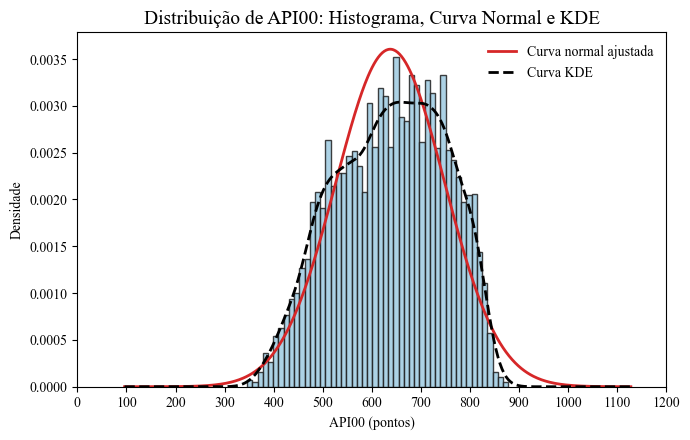

In [66]:
# Histograma de API00 com curva normal e KDE sobrepostas
# Dados e parâmetros da amostra
api00 = df['API00'].dropna()
mu = api00.mean()
sigma = api00.std(ddof=1)

# Grade de x para desenhar curvas suaves
grid_space = 500
x_grid = np.linspace(
    api00.min() - grid_space/2, 
    api00.max() + grid_space/2, 
    grid_space
)
normal_pdf = stats.norm.pdf(x_grid, loc=mu, scale=sigma)
kde_pdf = stats.gaussian_kde(api00)(x_grid)

# Histograma em escala de densidade
fig, ax = plt.subplots()
ax.hist(
    api00,
    bins=50,
    density=True,
    color='#9ecae1',
    edgecolor='#1f1f1f',
    alpha=0.85,
)

# Curva normal ajustada pelos parâmetros da amostra
ax.plot(
    x_grid,
    normal_pdf,
    color='#d62728',
    linewidth=2.0,
    label='Curva normal ajustada',
)

# Curva KDE para comparação não paramétrica
ax.plot(
    x_grid,
    kde_pdf,
    color='#000000',
    linewidth=2.0,
    linestyle='--',
    zorder=5,
    label='Curva KDE',
)

# Títulos, eixos e escala do gráfico
ax.set_title('Distribuição de API00: Histograma, Curva Normal e KDE')
ax.set_xlabel('API00 (pontos)')
ax.set_ylabel('Densidade')
ax.set_xlim(x_grid.min(), x_grid.max())

# Marcas do eixo X
dx = 100
x_tick_start = int(np.floor(x_grid.min() / dx) * dx)
x_tick_end = int(np.ceil(x_grid.max() / dx) * dx)
ax.set_xticks(np.arange(x_tick_start, x_tick_end + 1, dx))

# Legenda e finalização
ax.legend(loc='upper right', frameon=False)
fig.tight_layout()
plt.show()


**Fig. 8** **Histograma de API00 com curva normal ajustada e curva KDE.** O histograma em escala de densidade resume a distribuição empírica de `API00`, enquanto a curva normal (vermelha) usa os parâmetros da amostra ($\mu$ e $s$) e a curva KDE (preta) descreve a forma dos dados sem impor modelo paramétrico. A comparação visual sugere que `API00` apresenta **aproximação parcial** à normalidade, com desvios na forma em relação à curva normal teórica. Fonte: Carubbi, 2026.

## **Saiba mais**
1. [Medidas de Dispersão](https://en.wikipedia.org/wiki/Statistical_dispersion)
2. [Variância](https://pt.wikipedia.org/wiki/Vari%C3%A2ncia)
3. [Desvio padrão](https://pt.wikipedia.org/wiki/Desvio_padr%C3%A3o)
4. [Correção de Bessel](https://en.wikipedia.org/wiki/Bessel%27s_correction)
5. [Grau de liberdade](https://pt.wikipedia.org/wiki/Graus_de_liberdade)

## **Citação**

Estas aulas são baseadas no projeto de e-learning [SOGA-Py](https://www.geo.fu-berlin.de/en/v/soga-py/index.html) que foi desenvolvido no Departamento de Ciências da Terra por Annette Rudolph, Joachim Krois e Kai Hartmann. O contato pode ser realizado por e-mail, pelo endereço [soga[at]zedat.fu-berlin.de](soga[at]zedat.fu-berlin.de).

<p align="left">
  <a href="https://creativecommons.org/licenses/by-sa/4.0/" target="_blank" rel="noopener noreferrer">
    <img src="imgs/cc.png" width="75" alt="Licença Creative Commons BY-SA 4.0">
  </a>
</p>

Você pode utilizar este projeto livremente sob a Licença Creative Commons Attribution-ShareAlike 4.0 International. 

Por favor, cite da seguinte forma: Rudolph, A., Krois, J., Hartmann, K. (2023): Estatística e Análise de Geodados usando Python (SOGA-Py). Departamento de Ciências da Terra, Universidade Livre de Berlim.